<a href="https://www.kaggle.com/code/lalit7881/makeup-sales-in-2025-model-91-acc?scriptVersionId=306565446" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/syedaeman2212/makeup-sales-in-2025/makeup_sales_dataset_2025.csv


## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/syedaeman2212/makeup-sales-in-2025/makeup_sales_dataset_2025.csv")

In [3]:
df.head()

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,2025-11-24,Fenty Beauty,Eyeliner,UAE,Retail Store,Digital Wallet,17.80,48,854.40
1,2,2025-02-22,L'Oreal,Highlighter,USA,Online,Cash,82.82,35,2898.70
2,3,2025-04-22,Maybelline,Eyeliner,Germany,Retail Store,Card,31.76,39,1238.64
3,4,2025-10-29,MAC,Highlighter,France,Mall,Cash,36.99,1,36.99
4,5,2025-04-21,L'Oreal,Lipstick,Germany,Online,Card,115.08,22,2531.76


In [4]:
df.tail()

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
495,496,2025-09-25,L'Oreal,Highlighter,UAE,Beauty Salon,Card,84.15,40,3366.00
496,497,2025-12-06,MAC,Foundation,USA,Retail Store,Digital Wallet,82.77,25,2069.25
497,498,2025-08-29,L'Oreal,Eyeshadow,France,Retail Store,Card,102.97,11,1132.67
498,499,2025-05-23,NARS,Highlighter,UAE,Online,Card,10.79,15,161.85
499,500,2025-08-16,L'Oreal,Eyeshadow,Canada,Mall,Cash,97.15,29,2817.35


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sale_ID         500 non-null    int64  
 1   Date            500 non-null    object 
 2   Brand           500 non-null    object 
 3   Product_Type    500 non-null    object 
 4   Country         500 non-null    object 
 5   Sales_Channel   500 non-null    object 
 6   Payment_Method  500 non-null    object 
 7   Price_USD       500 non-null    float64
 8   Units_Sold      500 non-null    int64  
 9   Revenue_USD     500 non-null    float64
dtypes: float64(2), int64(2), object(6)
memory usage: 39.2+ KB


In [6]:
df.describe()

,Sale_ID,Price_USD,Units_Sold,Revenue_USD
count,500.000000,500.000000,500.000000,500.00000
mean,250.500000,62.857760,25.416000,1586.37700
std,144.481833,32.609632,14.217426,1284.13365
min,1.000000,5.250000,1.000000,25.64000
25%,125.750000,35.512500,13.000000,536.67250
50%,250.500000,61.225000,26.000000,1241.12500
75%,375.250000,90.775000,37.000000,2345.87750
max,500.000000,119.930000,50.000000,5987.50000


In [7]:
df.isnull().sum()

Sale_ID           0
Date              0
Brand             0
Product_Type      0
Country           0
Sales_Channel     0
Payment_Method    0
Price_USD         0
Units_Sold        0
Revenue_USD       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes


Sale_ID             int64
Date               object
Brand              object
Product_Type       object
Country            object
Sales_Channel      object
Payment_Method     object
Price_USD         float64
Units_Sold          int64
Revenue_USD       float64
dtype: object

In [10]:
df.shape

(500, 10)

In [11]:
df.columns

Index(['Sale_ID', 'Date', 'Brand', 'Product_Type', 'Country', 'Sales_Channel',
       'Payment_Method', 'Price_USD', 'Units_Sold', 'Revenue_USD'],
      dtype='object')

In [12]:
df.nunique()

Sale_ID           500
Date              264
Brand               8
Product_Type        8
Country             8
Sales_Channel       4
Payment_Method      3
Price_USD         494
Units_Sold         50
Revenue_USD       499
dtype: int64

## EDA

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

In [14]:
sns.set(style="whitegrid")


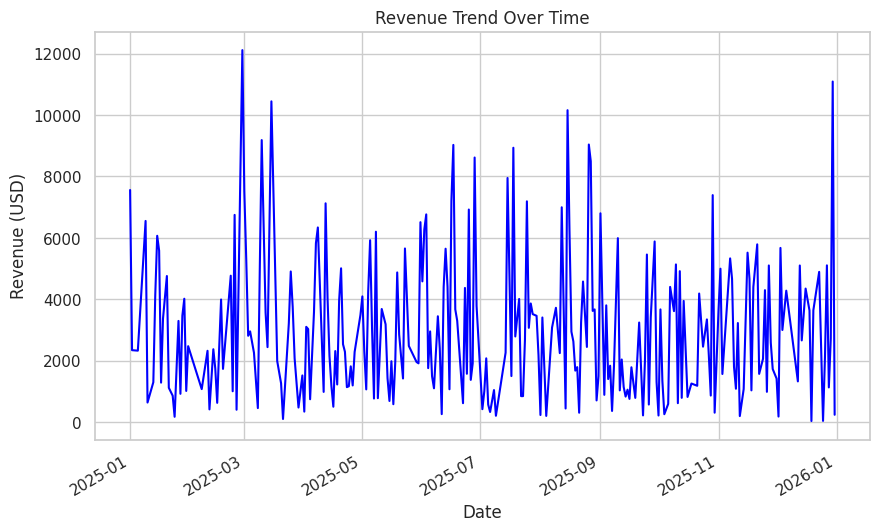

In [15]:
plt.figure(figsize=(10,6))
df.groupby('Date')['Revenue_USD'].sum().plot(color='blue')
plt.title("Revenue Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue (USD)")
plt.show()

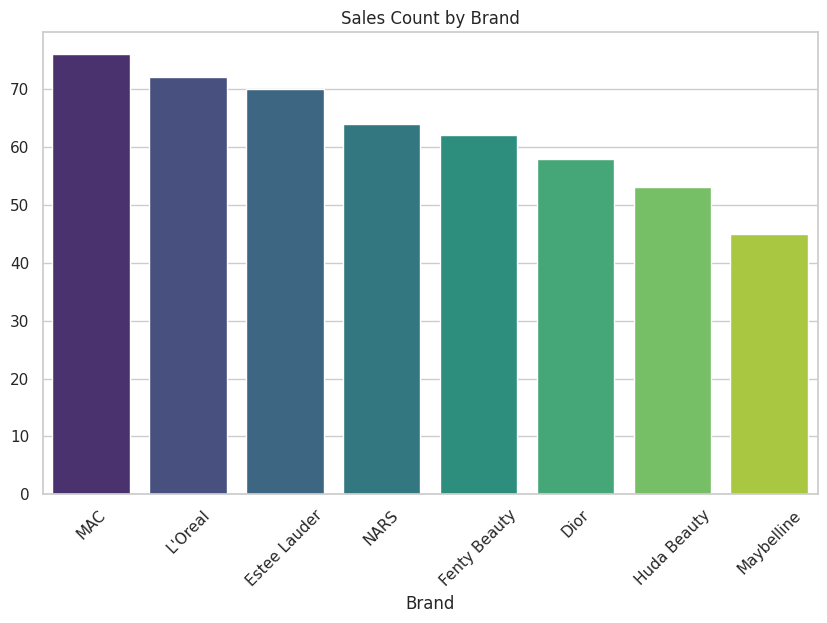

In [16]:
plt.figure(figsize=(10,6))
sns.barplot(x=df['Brand'].value_counts().index,
            y=df['Brand'].value_counts().values,
            palette='viridis')
plt.title("Sales Count by Brand")
plt.xticks(rotation=45)
plt.show()

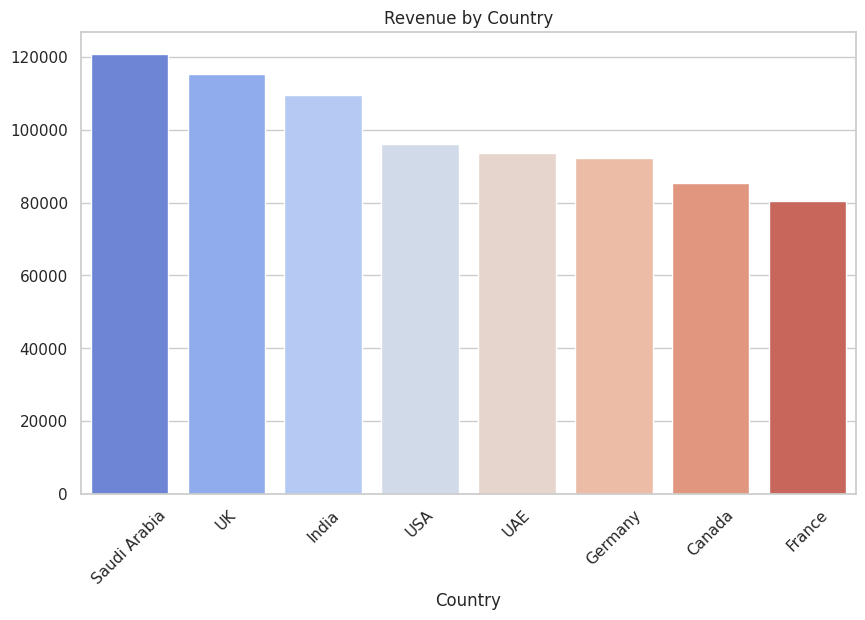

In [17]:
plt.figure(figsize=(10,6))
country_revenue = df.groupby('Country')['Revenue_USD'].sum().sort_values(ascending=False)
sns.barplot(x=country_revenue.index, y=country_revenue.values, palette='coolwarm')
plt.title("Revenue by Country")
plt.xticks(rotation=45)
plt.show()

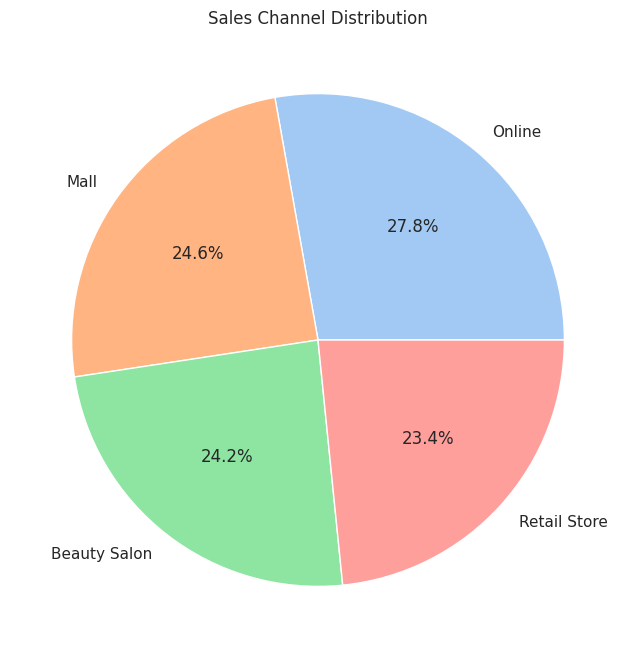

In [18]:
plt.figure(figsize=(8,8))
df['Sales_Channel'].value_counts().plot.pie(autopct='%1.1f%%',
                                           colors=sns.color_palette('pastel'))
plt.title("Sales Channel Distribution")
plt.ylabel('')
plt.show()

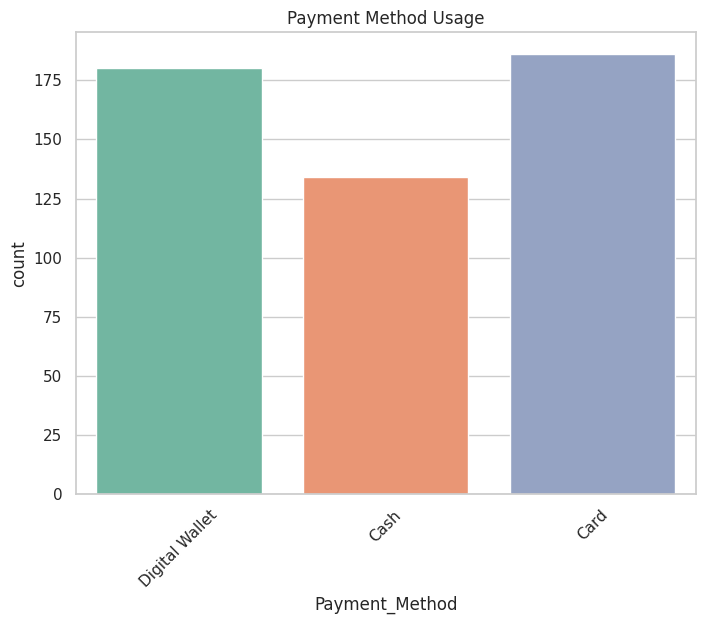

In [19]:
plt.figure(figsize=(8,6))
sns.countplot(x='Payment_Method', data=df, palette='Set2')
plt.title("Payment Method Usage")
plt.xticks(rotation=45)
plt.show()

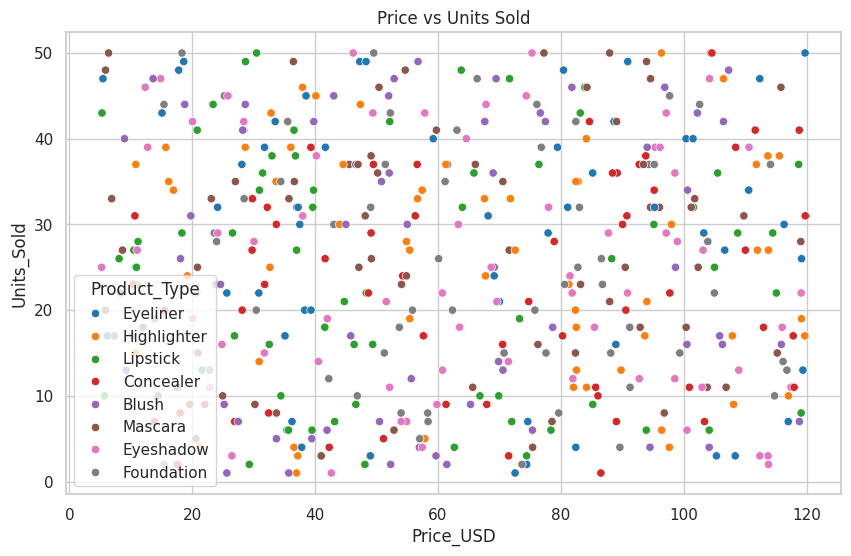

In [20]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Price_USD',
    y='Units_Sold',
    hue='Product_Type',
    palette='tab10'
)

plt.title("Price vs Units Sold")
plt.show()

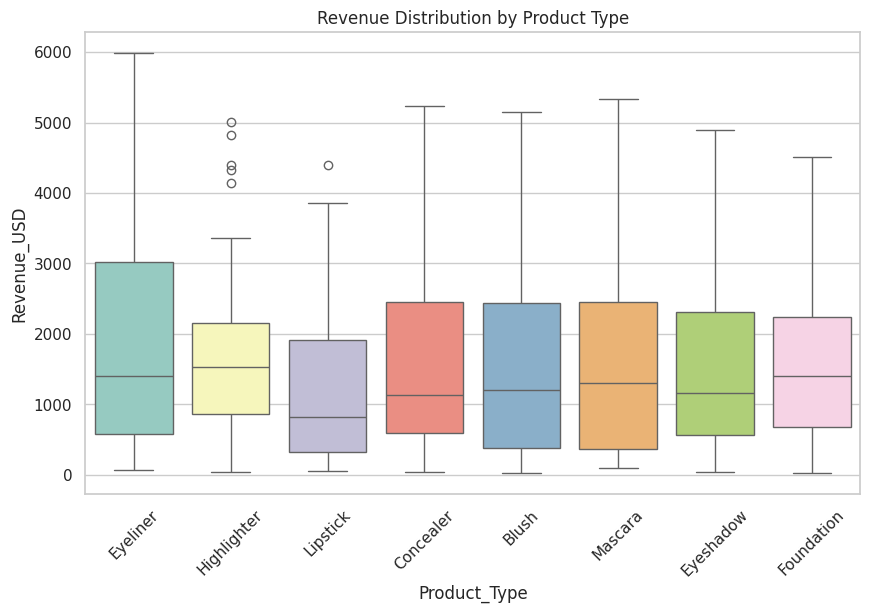

In [21]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Product_Type', y='Revenue_USD',
            data=df, palette='Set3')
plt.title("Revenue Distribution by Product Type")
plt.xticks(rotation=45)
plt.show()

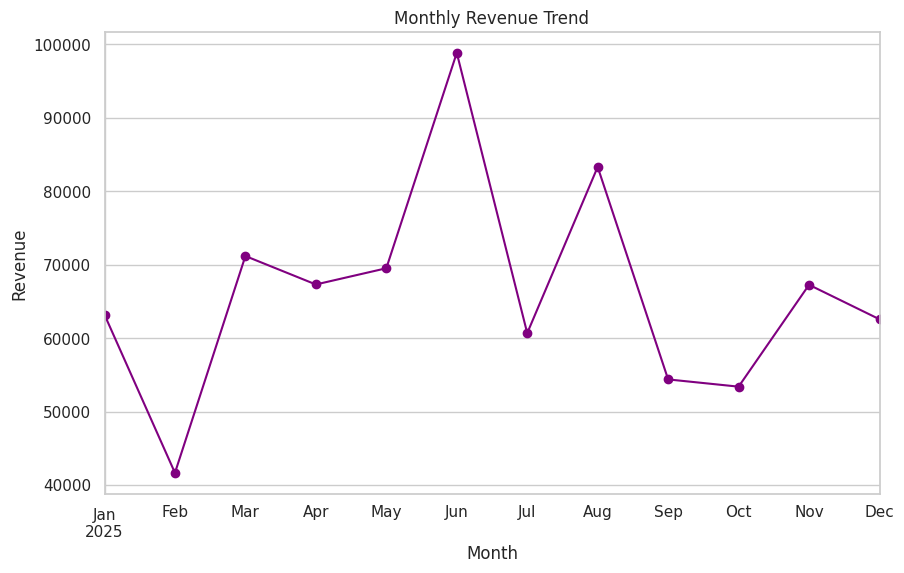

In [22]:
df['Month'] = df['Date'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['Revenue_USD'].sum()

plt.figure(figsize=(10,6))
monthly_revenue.plot(marker='o', color='purple')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

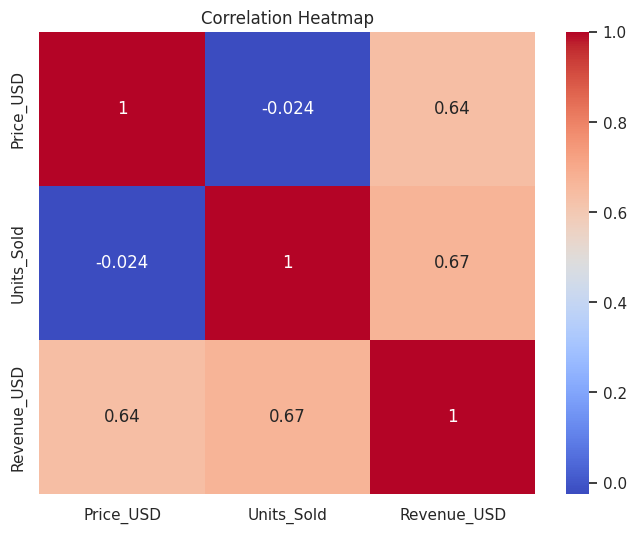

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Price_USD', 'Units_Sold', 'Revenue_USD']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Feature engineering

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [25]:
df.columns = df.columns.str.strip()

In [26]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

# Important derived features
df['Revenue_per_Unit'] = df['Revenue_USD'] / df['Units_Sold']
df['Price_per_Unit'] = df['Price_USD']


In [27]:
df['Revenue_Class'] = pd.qcut(
    df['Revenue_USD'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# Drop leakage columns
df = df.drop(['Sale_ID', 'Date', 'Revenue_USD'], axis=1)

In [28]:
X = df.drop('Revenue_Class', axis=1)
y = df['Revenue_Class']

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()


In [31]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

In [32]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        class_weight='balanced',
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    )
}

results = {}


Random Forest Accuracy: 0.8700

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        34
           1       0.89      1.00      0.94        33
           2       0.81      0.79      0.80        33

    accuracy                           0.87       100
   macro avg       0.87      0.87      0.87       100
weighted avg       0.87      0.87      0.87       100



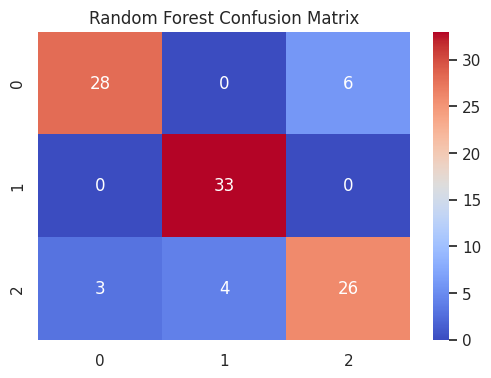


Gradient Boosting Accuracy: 0.9100

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92        34
           1       0.94      0.94      0.94        33
           2       0.83      0.91      0.87        33

    accuracy                           0.91       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.91      0.91      0.91       100



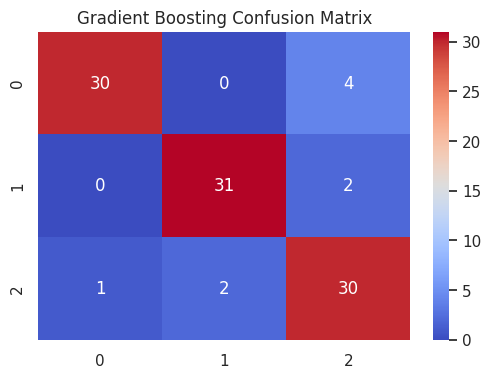

In [33]:
for name, model in models.items():
    
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n{name} Accuracy: {acc:.4f}")
    
    # Detailed report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred),
                annot=True, fmt='d', cmap='coolwarm')
    plt.title(f"{name} Confusion Matrix")
    plt.show()

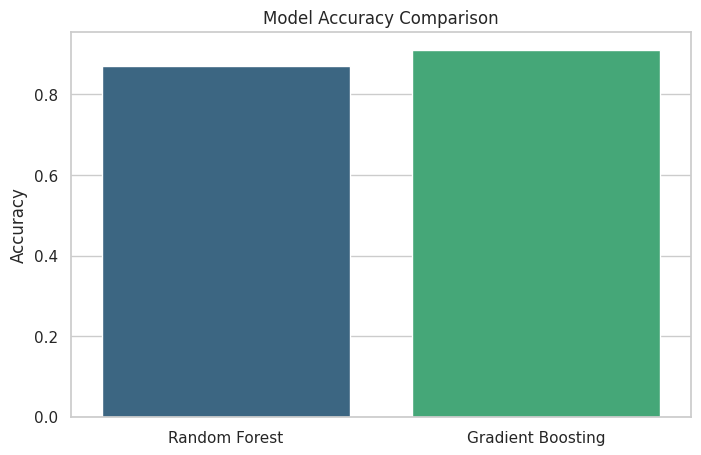

In [34]:
plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

## Thank you....pls upvote!!!!!!